# Análisis de la tasa de financiación de BTCUSDT Perpetuo en Binance

Ver [Funding strategy](../../docs/research/funding_strategy.md) para entender el contexto de este análisis.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [12]:
df = pd.read_csv(
    "../../data/binance/raw/Funding Rate History_BTCUSDT Perpetual_2026-06-01.csv"
)

In [13]:
df.head()

,Time,Contracts,Funding Interval,Funding Rate
0,2026-06-01 13:00:00,BTCUSDT Perpetual,8h,0.010000%
1,2026-06-01 05:00:00,BTCUSDT Perpetual,8h,0.004438%
2,2026-05-31 21:00:00,BTCUSDT Perpetual,8h,0.005703%
3,2026-05-31 13:00:00,BTCUSDT Perpetual,8h,0.005988%
4,2026-05-31 05:00:00,BTCUSDT Perpetual,8h,0.005663%


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7370 entries, 0 to 7369
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Time              7370 non-null   str  
 1   Contracts         7370 non-null   str  
 2   Funding Interval  7370 non-null   str  
 3   Funding Rate      7370 non-null   str  
dtypes: str(4)
memory usage: 230.4 KB


## Transformación de datos

In [15]:
df["Time"] = pd.to_datetime(df["Time"], utc=True)

In [16]:
df["Funding Rate"] = df["Funding Rate"].str.replace("%", "", regex=False).astype(float)

In [17]:
df["Time"] = pd.to_datetime(df["Time"])
df["Year"] = df["Time"].dt.year
df["Month"] = df["Time"].dt.month

## Analisis de la tasa de financiación por mes

In [31]:
df["Funding Rate"].describe()

count    7370.000000
mean        0.010807
std         0.021028
min        -0.300000
25%         0.002764
50%         0.010000
75%         0.010000
max         0.300000
Name: Funding Rate, dtype: float64

In [18]:
# monthly_funding_rate = (
#     df.set_index('Time')
#       .resample('ME')['Funding Rate']
#       .sum()
#       .reset_index()
# )

In [19]:
import pandas as pd
import plotly.graph_objects as go

daily = df.set_index("Time").resample("D")["Funding Rate"].sum().reset_index()

monthly = df.set_index("Time").resample("ME")["Funding Rate"].sum().reset_index()

yearly = df.set_index("Time").resample("YE")["Funding Rate"].sum().reset_index()

fig = go.Figure()

# Diario
fig.add_trace(
    go.Scatter(
        x=daily["Time"],
        y=daily["Funding Rate"],
        mode="lines+markers",
        name="Diario",
        visible=True,
    )
)

# Mensual
fig.add_trace(
    go.Scatter(
        x=monthly["Time"],
        y=monthly["Funding Rate"],
        mode="lines+markers",
        name="Mensual",
        visible=False,
    )
)

# Anual
fig.add_trace(
    go.Scatter(
        x=yearly["Time"],
        y=yearly["Funding Rate"],
        mode="lines+markers",
        name="Anual",
        visible=False,
    )
)

fig.update_layout(
    title="Funding Rate BTCUSDT",
    xaxis_title="Fecha",
    yaxis_title="Funding Rate (%)",
    updatemenus=[
        dict(
            buttons=[
                dict(
                    label="Diario",
                    method="update",
                    args=[{"visible": [True, False, False]}],
                ),
                dict(
                    label="Mensual",
                    method="update",
                    args=[{"visible": [False, True, False]}],
                ),
                dict(
                    label="Anual",
                    method="update",
                    args=[{"visible": [False, False, True]}],
                ),
            ],
            direction="down",
            x=1.1,
            y=1.15,
        )
    ],
)

fig.show()

In [20]:
funding_rate_pivot = df.pivot_table(
    index="Year", columns="Month", values="Funding Rate", aggfunc="sum"
)

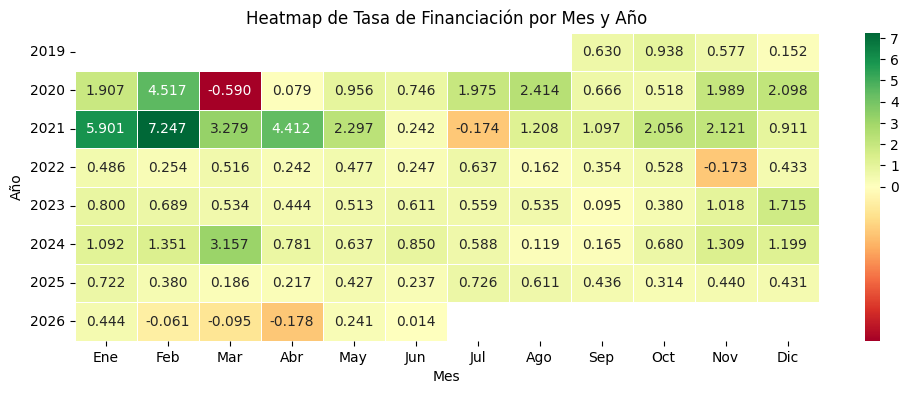

In [21]:
from matplotlib.colors import TwoSlopeNorm

# normalización centrada en 0
norm = TwoSlopeNorm(
    vmin=funding_rate_pivot.min().min(), vcenter=0, vmax=funding_rate_pivot.max().max()
)

plt.figure(figsize=(12, 4))

sns.heatmap(
    funding_rate_pivot,
    cmap="RdYlGn",  # 🔥 invertido para más contraste en rojos
    norm=norm,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
)

plt.title("Heatmap de Tasa de Financiación por Mes y Año")
plt.xlabel("Mes")
plt.ylabel("Año")

plt.xticks(
    ticks=np.arange(len(funding_rate_pivot.columns)) + 0.5,
    labels=[
        "Ene",
        "Feb",
        "Mar",
        "Abr",
        "May",
        "Jun",
        "Jul",
        "Ago",
        "Sep",
        "Oct",
        "Nov",
        "Dic",
    ],
)

plt.yticks(rotation=0)

plt.show()

In [27]:
annual = df.groupby("Year")["Funding Rate"].sum()

In [29]:
import plotly.graph_objects as go

fig_annual = go.Figure(
    go.Bar(
        x=annual.index.astype(str),
        y=annual.values,
        marker_color="indianred",
        name="Anual",
    )
)

# 🔥 línea promedio
mean_value = annual.mean()

fig_annual.add_hline(
    y=mean_value,
    line_dash="dash",
    line_color="blue",
    annotation_text="Promedio",
    annotation_position="top right",
)

fig_annual.update_layout(
    title="Funding Rate anual (suma por año)",
    xaxis_title="Año",
    yaxis_title="Funding Rate (%)",
    template="plotly_white",
)

fig_annual.show()

In [34]:
def simulate_funding_strategy(
    capital=2000,
    leverage=6.67,
    annual_funding_rate=0.1095,
    binance_taker_fee=0.0002,
    quantfury_fee=0,
    days=365,
):
    """
    Simula la estrategia delta-neutral de Funding Rate

    Parameters:
    -----------
    capital : float
        Capital total inmovilizado (USDT)
    leverage : float
        Apalancamiento aplicado (default 6.67x para 15% liquidación)
    annual_funding_rate : float
        Tasa de funding anual (default 10.95%)
    binance_taker_fee : float
        Comisión taker de Binance Futures (default 0.02%)
    quantfury_fee : float
        Comisión Quantfury Spot (default 0%)
    days : int
        Días de simulación (default 365)

    Returns:
    --------
    dict : Resumen de resultados
    """
    # Capital por posición
    capital_per_position = capital / 2

    # Capital efectivo en el mercado
    capital_efectivo = capital_per_position * leverage

    # Comisiones totales (entrada + salida en Binance Futures)
    fees_binance = 2 * binance_taker_fee * capital_efectivo
    fees_total = fees_binance + quantfury_fee

    # Ganancia bruta por funding
    ganancia_bruta = capital_efectivo * annual_funding_rate

    # Ganancia neta
    ganancia_neta = ganancia_bruta - fees_total

    # Rendimiento sobre capital inmovilizado
    rendimiento_pct = (ganancia_neta / capital) * 100

    # Rendimiento diario
    rendimiento_diario = ganancia_neta / days

    return {
        "capital_total": capital,
        "capital_por_posicion": capital_per_position,
        "capital_efectivo": capital_efectivo,
        "leverage": leverage,
        "fees_binance": fees_binance,
        "fees_total": fees_total,
        "ganancia_bruta": ganancia_bruta,
        "ganancia_neta": ganancia_neta,
        "rendimiento_anual_pct": rendimiento_pct,
        "rendimiento_diario": rendimiento_diario,
        "dias_simulacion": days,
    }


# Ejemplo de uso
resultado = simulate_funding_strategy(leverage=10, annual_funding_rate=0.0512)

print("=" * 50)
print("SIMULACIÓN ESTRATEGIA DELTA-NEUTRAL FUNDING")
print("=" * 50)
for key, value in resultado.items():
    if "pct" in key or "rendimiento" in key:
        print(f"{key:.<30} {value:.2f}%")
    else:
        print(f"{key:.<30} {value:,.2f}")

SIMULACIÓN ESTRATEGIA DELTA-NEUTRAL FUNDING
capital_total................. 2,000.00
capital_por_posicion.......... 1,000.00
capital_efectivo.............. 10,000.00
leverage...................... 10.00
fees_binance.................. 4.00
fees_total.................... 4.00
ganancia_bruta................ 512.00
ganancia_neta................. 508.00
rendimiento_anual_pct......... 25.40%
rendimiento_diario............ 1.39%
dias_simulacion............... 365.00
